In [1]:
#pip install scikit-learn pandas numpy matplotlib seaborn joblib
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import joblib, numpy as np
sns.set_theme(style='whitegrid', context='notebook')

In [2]:
#Load data California Housing Prices dataset
from pathlib import Path
USE_CALIFORNIA = True   # set False to use your own CSV
CSV_PATH = Path('my_housing.csv')
TARGET = 'SalePrice'

if USE_CALIFORNIA:
    from sklearn.datasets import fetch_california_housing
    cali = fetch_california_housing(as_frame=True)
    df = cali.frame.rename(columns={'MedHouseVal':'target'})
    y = df['target']; X = df.drop(columns=['target'])
    numeric_features = X.columns.tolist(); categorical_features = []
else:
    df = pd.read_csv(CSV_PATH)
    y = df[TARGET]; X = df.drop(columns=[TARGET])
    numeric_features = X.select_dtypes(include='number').columns.tolist()
    categorical_features = X.select_dtypes(exclude='number').columns.tolist()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
#Preprocessing + Linear Regression pipeline
preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
], remainder='drop')

model = Pipeline([
    ('preprocess', preprocess),
    ('reg', LinearRegression())
]).fit(X_train, y_train)

In [6]:
#Evaluate (MAE, RMSE, R²) vs a baseline
y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print(f"LinearRegression → R²={r2:.3f}  MAE={mae:.3f}  RMSE={rmse:.3f}")

baseline = np.full_like(y_test, y_train.mean(), dtype=float)
mse_baseline = mean_squared_error(y_test, baseline)
rmse_baseline = mse_baseline ** 0.5
print("Baseline(mean)  →",
      f"R²={r2_score(y_test, baseline):.3f}",
      f"MAE={mean_absolute_error(y_test, baseline):.3f}",
      f"RMSE={rmse_baseline:.3f}")

LinearRegression → R²=0.576  MAE=0.533  RMSE=0.746
Baseline(mean)  → R²=-0.000 MAE=0.906 RMSE=1.145


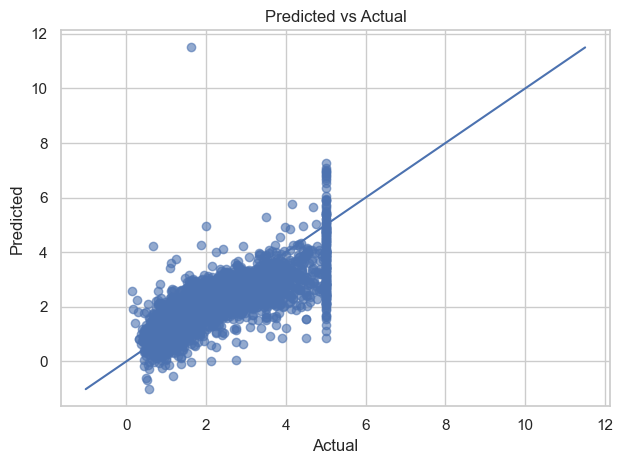

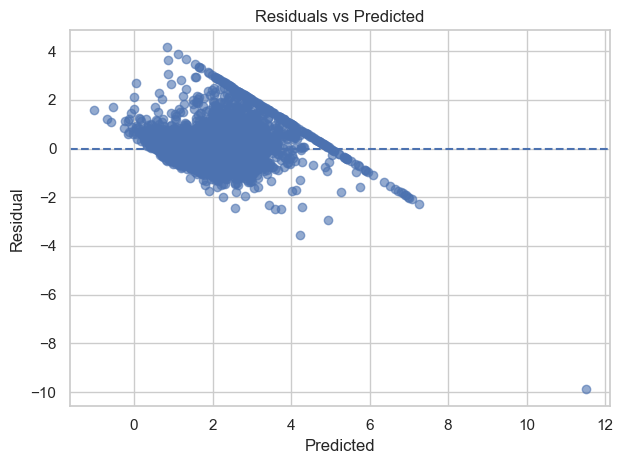

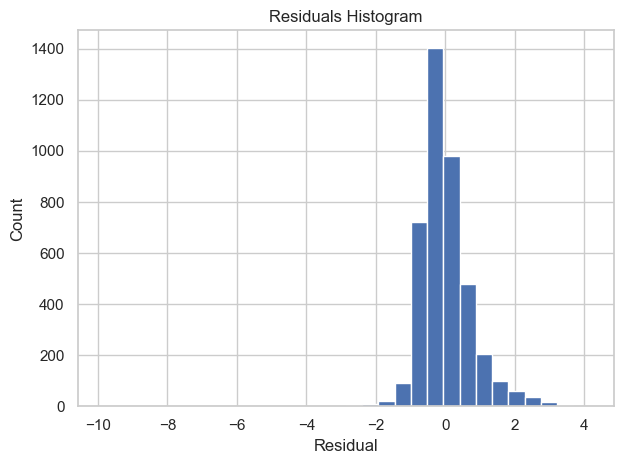

In [7]:
#Visual diagnostics
import matplotlib.pyplot as plt
resid = y_test - y_pred

# Predicted vs Actual
plt.figure(); 
plt.scatter(y_test, y_pred, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims)
plt.title('Predicted vs Actual'); plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.tight_layout(); plt.show()

# Residuals vs Predicted
plt.figure();
plt.scatter(y_pred, resid, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.title('Residuals vs Predicted'); plt.xlabel('Predicted'); plt.ylabel('Residual'); plt.tight_layout(); plt.show()

# Residuals histogram
plt.figure(); 
plt.hist(resid, bins=30)
plt.title('Residuals Histogram'); plt.xlabel('Residual'); plt.ylabel('Count'); plt.tight_layout(); plt.show()

In [8]:
#Feature effects (coefficients & permutation importance)
# Coefficients (on transformed features)
def get_feature_names(preprocess, num_feats, cat_feats):
    names = []
    names += list(num_feats)
    if len(cat_feats):
        names += preprocess.named_transformers_['cat'].get_feature_names_out(cat_feats).tolist()
    return names

feat_names = get_feature_names(model.named_steps['preprocess'], numeric_features, categorical_features)
coef_df = (pd.DataFrame({'feature': feat_names, 'coef': model.named_steps['reg'].coef_})
             .sort_values('coef', key=abs, ascending=False))
coef_df.head(12)

# Permutation importance (model-agnostic)
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=0)
pi = pd.DataFrame({'feature': list(X.columns), 'importance': perm.importances_mean}).sort_values('importance', ascending=False)
pi.head(12)

,feature,importance
6,Latitude,1.223803
7,Longitude,1.151447
0,MedInc,1.058287
3,AveBedrms,0.259454
2,AveRooms,0.234675
1,HouseAge,0.022661
5,AveOccup,0.001001
4,Population,0.000025


In [9]:
#Cross‑validation (optional)
from sklearn.model_selection import cross_val_score
neg_rmse = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=5)
print("CV RMSE (5‑fold):", -neg_rmse.mean(), "±", neg_rmse.std())

CV RMSE (5‑fold): 0.7459068363518113 ± 0.043739721675926


In [10]:
#Save model & predictions
import joblib
joblib.dump(model, 'linreg_house_prices.joblib')
pd.DataFrame({'y_test': y_test, 'y_pred': y_pred}).to_csv('test_predictions.csv', index=False)


In [11]:
# Compare LinearRegression, Ridge and Lasso (MAE / RMSE / R²)
from sklearn.linear_model import Ridge, Lasso
models = {
    'Linear': Pipeline([('preprocess', preprocess), ('reg', LinearRegression())]),
    'Ridge' : Pipeline([('preprocess', preprocess), ('reg', Ridge(alpha=1.0))]),
    'Lasso' : Pipeline([('preprocess', preprocess), ('reg', Lasso(alpha=0.01, max_iter=10000))])
}
results = []
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    y_pred_m = mdl.predict(X_test)
    r2 = r2_score(y_test, y_pred_m)
    mae = mean_absolute_error(y_test, y_pred_m)
    mse = mean_squared_error(y_test, y_pred_m)
    rmse = mse ** 0.5
    results.append((name, r2, mae, rmse))
import pandas as pd
res_df = pd.DataFrame(results, columns=['model','R2','MAE','RMSE']).set_index('model')
print(res_df)


              R2       MAE      RMSE
model                               
Linear  0.575788  0.533200  0.745581
Ridge   0.575816  0.533193  0.745557
Lasso   0.581615  0.535326  0.740442


Poly(deg2) LinearRegression → R²=0.646  MAE=0.467  RMSE=0.681


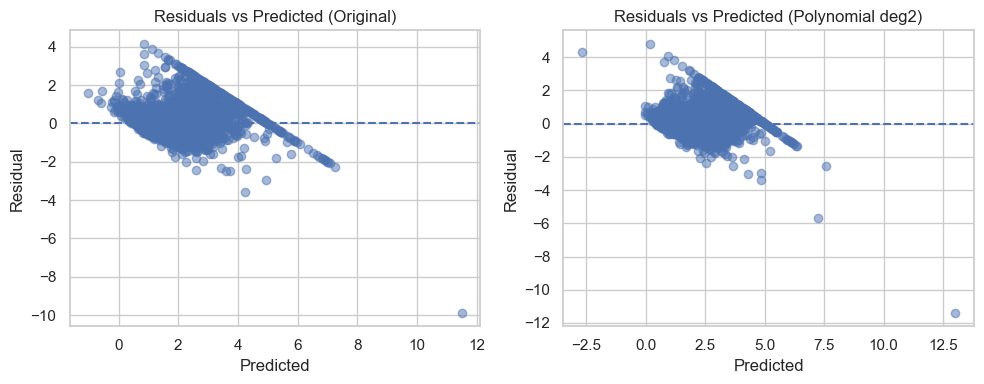

In [12]:
# Add PolynomialFeatures(degree=2) to numeric columns and evaluate
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline as _Pipeline
# build a preprocessing pipeline that adds polynomial features to numeric columns
poly_preprocess = ColumnTransformer([
    ('num', _Pipeline([('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=2, include_bias=False))]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
], remainder='drop')
poly_model = Pipeline([('preprocess', poly_preprocess), ('reg', LinearRegression())]).fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)
r2_p = r2_score(y_test, y_pred_poly)
mae_p = mean_absolute_error(y_test, y_pred_poly)
rmse_p = mean_squared_error(y_test, y_pred_poly) ** 0.5
print(f'Poly(deg2) LinearRegression → R²={r2_p:.3f}  MAE={mae_p:.3f}  RMSE={rmse_p:.3f}')

# Compare residual plots: original vs polynomial
resid_orig = y_test - y_pred
resid_poly = y_test - y_pred_poly
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(y_pred, resid_orig, alpha=0.5)
plt.axhline(0, linestyle='--')
plt.title('Residuals vs Predicted (Original)')
plt.xlabel('Predicted'); plt.ylabel('Residual')
plt.subplot(1,2,2)
plt.scatter(y_pred_poly, resid_poly, alpha=0.5)
plt.axhline(0, linestyle='--')
plt.title('Residuals vs Predicted (Polynomial deg2)')
plt.xlabel('Predicted'); plt.ylabel('Residual')
plt.tight_layout(); plt.show()


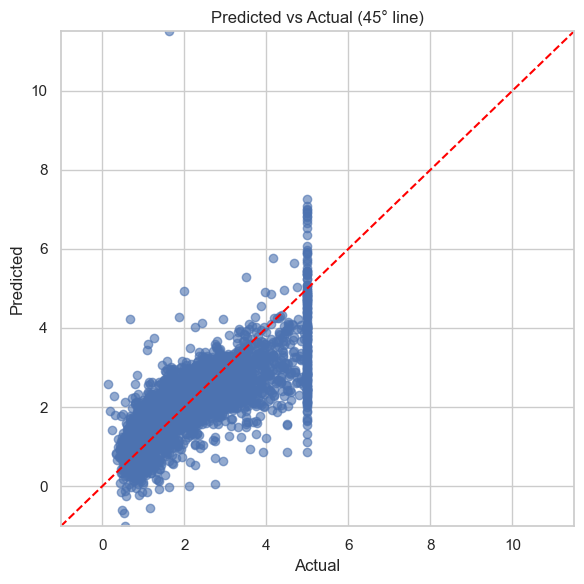

Median absolute error = 0.410


In [13]:
# Predicted vs Actual with 45° line and median absolute error
import numpy as np
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linestyle='--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual (45° line)')
plt.tight_layout(); plt.show()
medae = np.median(np.abs(y_test - y_pred))
print(f'Median absolute error = {medae:.3f}')
